In [13]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os
load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("Google API Key is set.")
else:
    raise ValueError("Google API Key is not set.")

Google API Key is set.


In [14]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
# llm.invoke("I want to know the meaning of water").content

# **First Graph**

### **Step-1: Define The Schema**
#
State Schema in LangGraph
#
A State Schema defines the structure of data that flows through the graph. It acts as a shared memory for all nodes, specifying what information each node can read, update, and pass to other nodes. In LangGraph, schemas are commonly defined using TypedDict or Pydantic models to ensure consistent state management across the workflow.Schema should not be changed. We first define the schema then build our graph.

Key Idea: State = Shared data container for the entire graph.

In [2]:
# This is a lightweight schema for the response from the LLM. 
from typing import TypedDict,List

class graph_schema(TypedDict):
    name: str
    message: str

### **Step-2: Create The Node Functions**

### Node Functions in LangGraph

A **Node Function** represents an individual step or operation in the graph. Each node receives the current state as input, performs a specific task (such as calling an LLM, processing data, or making a decision), and returns updates to the state. Nodes are the building blocks that define the workflow logic of a LangGraph application.

**Key Idea:** Node = A unit of work that reads state, performs an action, and updates state.


In [6]:
# So in this we are building a single function only to get the ides so here it will be only one function
# here the state variable will be available for each node by default in langgraph.
# And also this state variable will contain the data type that we have defined above in schema(graph_schema).
def welcome(state:graph_schema) -> graph_schema:
    
    curr_name = state['name']
    curr_message = state['message']

    response = llm.invoke(f"My name is {curr_name}.{curr_message}").content

    state['message'] = f"Your message was {curr_message}. Here's my response:  {response}"

    return state
    

### **Step-3: Create The State Graph**
### State Graph in LangGraph

A **StateGraph** is the core workflow structure in LangGraph that manages how nodes interact through a shared state. It is created using the state schema and acts as a container where nodes and edges are added to define the execution flow. The StateGraph coordinates data movement and execution between different nodes in the graph.

**Key Idea:** StateGraph = Workflow blueprint that connects nodes using a shared state.

In [ ]:
# here start and End are by default node that you should always have whenever you are creating a node
from langgraph.graph import StateGraph, START, END

# create the instance of the graph and pass the state(schema) in it
graph = StateGraph(graph_schema)

# Adding Nodes
graph.add_node("welcome", welcome)

# Adding Edges
# create one edge from start node to node "welcome"
graph.add_edge(START, "welcome")
# then create a second node from "welcome" to end.
graph.add_edge("welcome", END)



### **Step-4 Compile The Graph**
### Compile the Graph

Compiling the graph converts the defined StateGraph into an executable workflow. During compilation, LangGraph validates the nodes, edges, and state transitions, then prepares the graph for execution.

**Key Idea:** Compile = Validate and transform the graph into a runnable application.

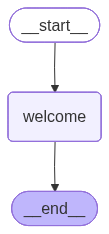

In [ ]:
# This python library helps to display the graph
from IPython.display import Image, display

first_graph = graph.compile()


Image(first_graph.get_graph().draw_mermaid_png())

# You can use the below command to see the graph without errors
# print(first_graph.get_graph().draw_mermaid())

### **Step-5: Run The Graph**
### Run the Graph

Running the graph executes the compiled workflow by passing an initial state as input. The graph processes the state through connected nodes, updates it at each step, and returns the final state as the output.

**Key Idea:** Run = Execute the workflow with an input state and get the final result.


In [16]:
first_graph.invoke({"name":"shrinath","message":"How are you?"})

{'name': 'shrinath',
 'message': "Your message was How are you?. Here's my response:  Hello Shrinath! I'm doing well, thank you for asking.\n\nHow are you doing today?"}